In [15]:
import seaborn as sns

# Load Titanic dataset
titanic = sns.load_dataset("titanic")

# Inspect first 5 rows
print(titanic.head())
print(titanic.describe())
print(titanic.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.3815

In [27]:
titanic.skew(numeric_only=True)

survived      0.478523
pclass       -0.630548
age           0.389108
sibsp         3.695352
parch         2.749117
fare          4.787317
adult_male   -0.420431
alone        -0.420431
dtype: float64

In [31]:
print(titanic.isnull().sum().to_string())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0


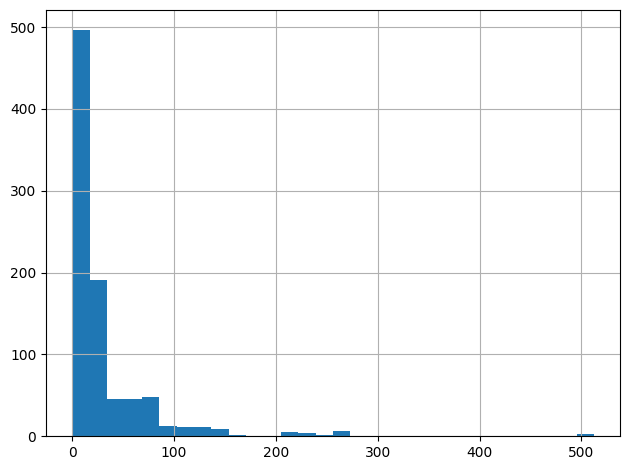

In [29]:
import matplotlib.pyplot as plt

titanic["fare"].hist(bins=30)
plt.show()


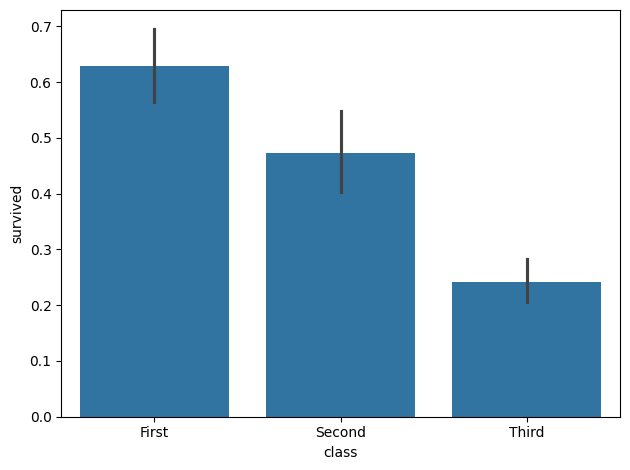

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=titanic, x="class", y="survived")

plt.tight_layout()
plt.show()


In [24]:
import matplotlib.pyplot as plt

plt.rcParams["figure.autolayout"] = True


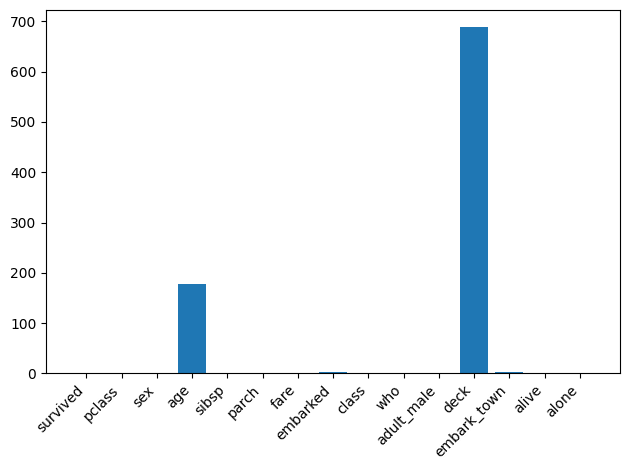

In [26]:
# fig, ax = plt.subplots(constrained_layout=True)
plt.bar(titanic.isnull().sum().index, titanic.isnull().sum().values)
plt.xticks(rotation=45, ha="right")
plt.show()
# plt.tight_layout()

In [7]:
numeric_cols = titanic.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()
corr_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [ ]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

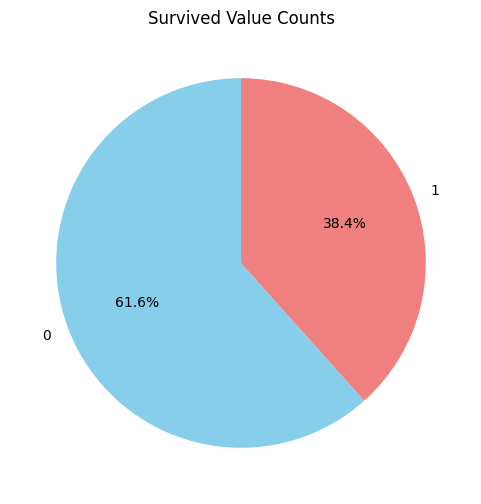

In [7]:
import matplotlib.pyplot as plt

# Count the values in the label column
value_counts = titanic['survived'].value_counts()

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title("Survived Value Counts")

# Save the chart to a file
plt.savefig("survived_pie_chart.png")

# Optional: Show the chart
plt.show()


In [1]:

from analyst.nodes import analyst_call
from preprocessor.nodes import preprocessor_call
from state import should_continue, MessagesState, make_tool_node, ask_user_node, should_continue_with_user
from langgraph.graph import StateGraph, START, END
from analyst.tools import tools_by_name as analyst_tools
from preprocessor.tools import tools_by_name as preprocessor_tools
from langgraph.checkpoint.memory import InMemorySaver
import uuid



# Build workflow
agent_builder = StateGraph(MessagesState)
analyst_tool_node = make_tool_node(analyst_tools)
preprocessor_tool_node = make_tool_node(preprocessor_tools)

# Add nodes
agent_builder.add_node("analyst", analyst_call)
agent_builder.add_node("analyst_tools", analyst_tool_node)
agent_builder.add_node("preprocessor", preprocessor_call)
agent_builder.add_node("preprocessor_tools", preprocessor_tool_node)
# agent_builder.add_node("user_input",ask_user_node)


# Add edges to connect nodes
agent_builder.add_edge(START, "analyst")
agent_builder.add_conditional_edges(
    "analyst",
    should_continue,
    ["analyst_tools", "preprocessor"]
)
agent_builder.add_edge("analyst_tools", "analyst")


agent_builder.add_conditional_edges(
    "preprocessor",
    should_continue_with_user,
    ["preprocessor_tools", END]
)
agent_builder.add_edge("preprocessor_tools", "preprocessor")

# Compile the agent
# checkpointer = InMemorySaver()
agent = agent_builder.compile()

# config = {
#     "configurable": {
#         "thread_id": uuid.uuid4(),
#     }
# }
# print(config)
# from langchain.messages import HumanMessage, SystemMessage
# messages = [SystemMessage(content="dataset address: \"datasets/Titanic-Dataset.csv\""),HumanMessage(content="Analyze the data")]
# gen=agent.stream({"messages":messages},config)
# first_chunk=next(gen)
# print(first_chunk)
# print(messages)
# Show the agent
# from IPython.display import Image, display
# display(Image(agent.get_graph(xray=True).draw_mermaid_png()))



InvalidUpdateError: Expected dict, got [SystemMessage(content="You are an expert data preprocessor and handler tasked with recommending and performing data handling tasks on behalf of a user. Your instructions: \n                        - Examine the columns with null data from the null values section in the given context.\n                        - For each column with nulls recommend an action either to replace with average value, drop all rows with null for this column, or drop the column entirely. This will be based on the data provided.\n                        - Based on what the user says you will call either the drop_rows, drop_column, or replace_with_avg with the column name as the column_name argument and the dataset address in the data argument\n\n                        Steps: \n                        1- Examine first column data\n                        2- query user using ask_user tool giving your query in the question argument. Your query will 1. inform the user of the 

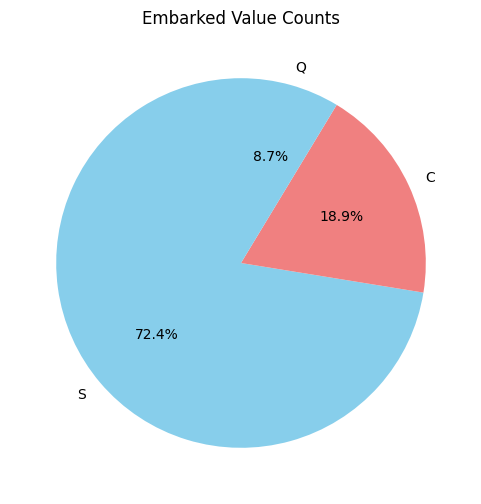

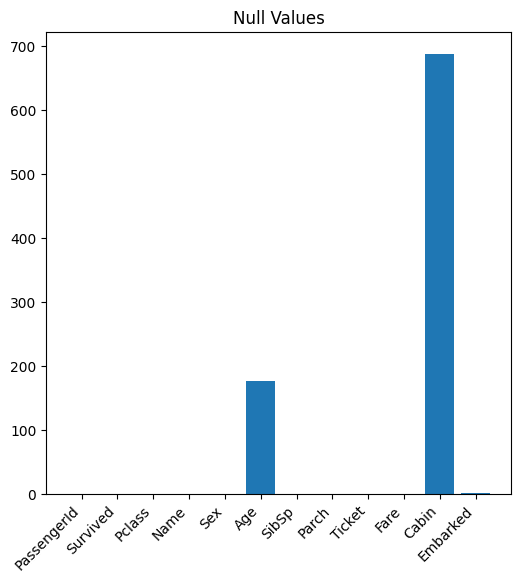

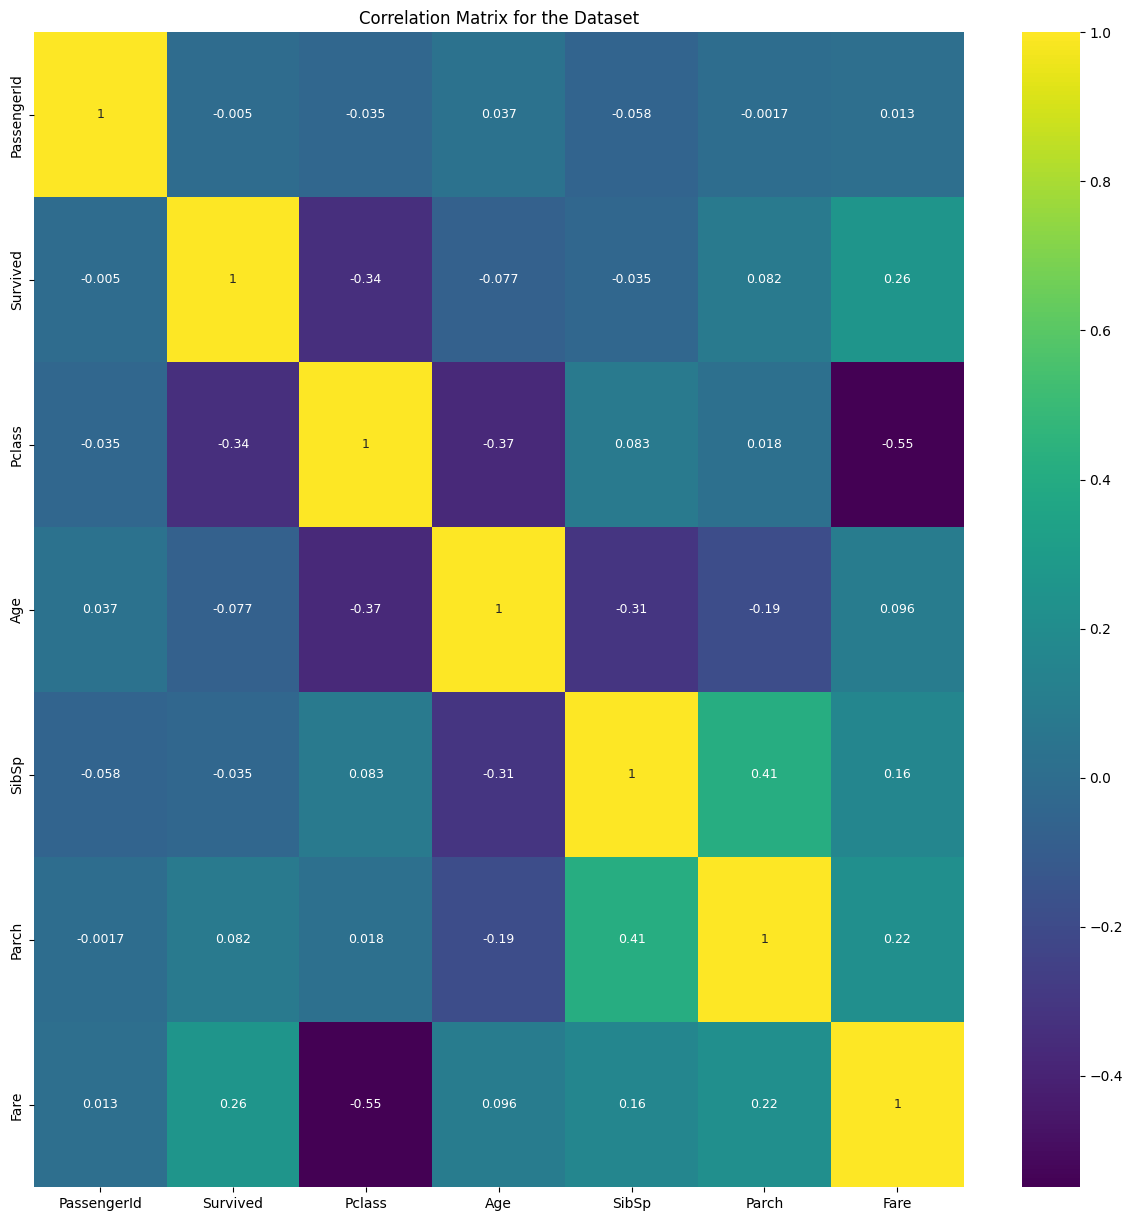

In [2]:
# Invoke
from langchain.messages import HumanMessage, SystemMessage
messages = [SystemMessage(content="dataset address: \"datasets/Titanic-Dataset.csv\""),HumanMessage(content="Analyze the data")]
messages = agent.invoke({"messages": messages})
# for m in messages["messages"]:
#     m.pretty_print()

In [3]:
messages

{'messages': [SystemMessage(content='dataset address: "datasets/Titanic-Dataset.csv"', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Analyze the data', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'analyse_data', 'arguments': '{"data": "datasets/Titanic-Dataset.csv"}'}, '__gemini_function_call_thought_signatures__': {'6145755d-6be9-4844-9783-99197cc23de8': 'CqcCAb4+9vvQyEUAzGTM8VKkZM+LEfPQ2mC9FuGxrexv8mfpIj+EJ0zE0okoJiicDwbC1FLBsuHlSPBwbWNi/crXjFDj/seT8al1g6ZgKagg4P6fFqiI42yn62sXt5zZk9u8rMrrTIlgbeF3YDmOOM86ijjsrQh3spY34+r3ZpL0af05R60Nhwu2e3Sk0uLSJMRMr8kklctBc0UsHlIC1P3uSpzgokL+f8TI4vKrXy/Xv0U0h2f4zOfveDioL8SJRuZhJsAhaLCiP67D9Qkj7l9c28NiQ6F5Es2GwvGC4Ak/7Y9OXcYwjZO8UAmo2ssK3jF6gdcIl0aNrk+b9cWg7sKOVXXY+fxDQRMe6mnQqDSZgv3aa7N8vmv/T+R6LbAqvo0Y0SvA4xKMjw=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_r

In [8]:
input("Enter")

'sup'

In [7]:
for message in messages['messages'][-2:]:
    print(message.content[0]['text'])

---

### **Description of the Data**
The Titanic dataset contains **891 rows** and **12 columns**. It is a classic dataset used for binary classification tasks, where the goal is to predict survival.

- **Label Column:** `Survived` (Binary: 0 = No, 1 = Yes)
- **Data Types:**
    - **Numeric:** `PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`
    - **Categorical/Text:** `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`

---

### **Data Imbalance**
The dataset shows a moderate imbalance between the target classes. Approximately **38.4%** of the passengers survived, while **61.6%** did not. While there is a difference, it is not extreme enough to severely hinder standard machine learning models, though techniques like stratified sampling might still be beneficial.

![Label Pie Chart](images/label_pie_chart.png)

---

### **Null Values**
Several columns contain missing information that will require preprocessing:

- **Cabin:** This column has a significantly high number of n

In [13]:
report = messages['messages'][-1].content[0]['text']

In [14]:
with open("report.md","w", encoding="utf-8") as f:
    f.write(report)